<a href="https://colab.research.google.com/github/JohnnySolo/Data-Analysis-Project---Hybrid-Cyber-Threat-Detection/blob/main/03_Feature_Engineering_and_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering

### Data Preparation & Dimensionality Reduction (Based on our handoff from Notebook 2)

* **Load the Data**: Read the clean Parquet data.

* **Collinearity Drop**: Based on our correlation heatmap, we will drop the redundant timing features (e.g., dropping `Flow IAT Max` and `Fwd IAT Mean` while keeping `Fwd IAT Max`) to prevent our models from overfitting.

* **Label Encoding & Splitting**: Convert 'Benign', 'Bot', and 'Infilteration' into numerical values. We will use a **Stratified** Train-Test Split to ensure the tiny percentage of attacks is properly represented in both the training and testing sets.

## Load The Data

In [2]:
import numpy as np
from google.colab import drive
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler

print("Initializing Step 1: Data Preparation & Dimensionality Reduction...")

# Install PySpark (since this is a new notebook environment)
!pip install pyspark

# 1. Start Spark Session (Ensure only one SparkSession is initialized)
spark = SparkSession.builder.appName("Cyber_Modeling").getOrCreate()

# Mount Google Drive
drive.mount('/content/drive')

# 2. Load the Data (Using the wildcard to grab all 4 parquet parts)
# Defining the path to the folder containing the data files
base_path = "/content/drive/MyDrive/Projects/Hybrid Cyber Threat Detection/"
# Using the wildcard (*) to explicitly tell PySpark to read all the 'part-' files
files_to_load = base_path + "part-*.parquet"

# Load and combine the 4 files into a single DataFrame
df = spark.read.parquet(files_to_load)

Initializing Step 1: Data Preparation & Dimensionality Reduction...
Mounted at /content/drive


In [ ]:
final_features = ["Dst Port", "Fwd IAT Max", "Fwd Pkts/s", "Flow Duration",
                        "Bwd Seg Size Avg", "Bwd Pkts/s", "Fwd Pkt Len Std", "Bwd Pkt Len Std"]

engineered_features = final_features + ["Fwd_Pkts_s_RollMean", "Fwd_IAT_Max_RollMax", "Bwd_Seg_Size_RollMean"]

In [6]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, mean, max, to_timestamp
from pyspark.ml.feature import StringIndexer, VectorAssembler
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("--- 1. Temporal Feature Engineering & Scaling ---")

# The 8 orthogonal features we finalized
final_features = ["Dst Port", "Fwd IAT Max", "Fwd Pkts/s", "Flow Duration",
                        "Bwd Seg Size Avg", "Bwd Pkts/s", "Fwd Pkt Len Std", "Bwd Pkt Len Std"]

# Temporarily keep Timestamp for chronological sorting
df = df.withColumn("Parsed_Timestamp", to_timestamp(col("Timestamp"), "dd/MM/yyyy HH:mm:ss"))
columns_to_keep = final_features + ["Label", "Parsed_Timestamp"]
df_reduced = df.select(*columns_to_keep)

# Create rolling windows (last 10 connections) partitioned by Destination Port
# FIX: Using Window.currentRow instead of Window.currentTime
windowSpec = Window.partitionBy("Dst Port").orderBy("Parsed_Timestamp").rowsBetween(-9, Window.currentRow)

df_engineered = df_reduced.withColumn("Fwd_Pkts_s_RollMean", mean(col("Fwd Pkts/s")).over(windowSpec)) \
                         .withColumn("Fwd_IAT_Max_RollMax", max(col("Fwd IAT Max")).over(windowSpec)) \
                         .withColumn("Bwd_Seg_Size_RollMean", mean(col("Bwd Seg Size Avg")).over(windowSpec))

df_engineered = df_engineered.drop("Parsed_Timestamp")
engineered_features = final_features + ["Fwd_Pkts_s_RollMean", "Fwd_IAT_Max_RollMax", "Bwd_Seg_Size_RollMean"]

# Encode labels and assemble vectors
indexer = StringIndexer(inputCol="Label", outputCol="Label_Index")
df_indexed = indexer.fit(df_engineered).transform(df_engineered)

assembler = VectorAssembler(inputCols=engineered_features, outputCol="features")
df_assembled = assembler.transform(df_indexed)

# Stratified Split (80/20)
fractions = {'Benign': 0.8, 'Bot': 0.8, 'Infilteration': 0.8}
train_data = df_assembled.sampleBy("Label", fractions, seed=42)
test_data = df_assembled.subtract(train_data)

# Convert to Pandas
train_pdf = train_data.select(*engineered_features, "Label", "Label_Index").toPandas()
test_pdf = test_data.select(*engineered_features, "Label", "Label_Index").toPandas()

X_train = train_pdf[engineered_features]
y_train = train_pdf['Label_Index'] # 0.0: Benign, 1.0: Bot, 2.0: Infiltration
X_test = test_pdf[engineered_features]
y_test = test_pdf['Label_Index']

# Scale the data (Mandatory for Autoencoder distance calculations)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Data engineered, split, and scaled successfully.")

--- 1. Temporal Feature Engineering & Scaling ---
Data engineered, split, and scaled successfully.


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

print("--- 2. Autoencoder Feature Extraction ---")

# Isolate ONLY Benign traffic so the network learns the "normal" baseline perfectly
X_train_benign = X_train_scaled[y_train == 0.0]

# Build a deep Autoencoder architecture
input_dim = X_train_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(4, activation='relu')(encoded) # Bottleneck/Latent Space
decoded = Dense(8, activation='relu')(encoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the Autoencoder
print("Training Autoencoder on Benign traffic...")
autoencoder.fit(X_train_benign, X_train_benign, epochs=10, batch_size=256, validation_split=0.1, verbose=0)

# Calculate Reconstruction Error for the entire Train and Test sets
print("Extracting Reconstruction Error features...")
train_reconstructions = autoencoder.predict(X_train_scaled)
test_reconstructions = autoencoder.predict(X_test_scaled)

mse_train = np.mean(np.power(X_train_scaled - train_reconstructions, 2), axis=1)
mse_test = np.mean(np.power(X_test_scaled - test_reconstructions, 2), axis=1)

# Inject the error as a new, highly-sensitive predictive feature
# FIX: Ensure these are 2D DataFrames for Scikit-Learn compatibility
X_train_enh = pd.DataFrame(mse_train, columns=['Reconstruction_Error'])
X_test_enh = pd.DataFrame(mse_test, columns=['Reconstruction_Error'])

print("Autoencoder feature added. Moving to model training.")

--- 2. Autoencoder Feature Extraction ---
Training Autoencoder on Benign traffic...
Extracting Reconstruction Error features...
35717/35717 ━━━━━━━━━━━━━━━━━━━━ 51s 1ms/step
8918/8918 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step
Autoencoder feature added. Moving to model training.


# Unsupervised Anomaly Detection (Isolation Forest)

* **The Objective**: Prove we can detect 'Zero-Day' threats without relying on known labels.

* **Execution**: We will train an Isolation Forest model to map out the 'normal' human variance of Benign traffic, and flag the extreme timing rigidity (Botnet) and two-stage extremes (Infiltration) as anomalies.

STEP 2: ISOLATION FOREST (UNSUPERVISED)

Isolation Forest Performance (Normal vs Anomaly):
              precision    recall  f1-score   support

      Normal       0.75      0.75      0.75    224454
     Anomaly       0.07      0.07      0.07     60902

    accuracy                           0.61    285356
   macro avg       0.41      0.41      0.41    285356
weighted avg       0.61      0.61      0.61    285356



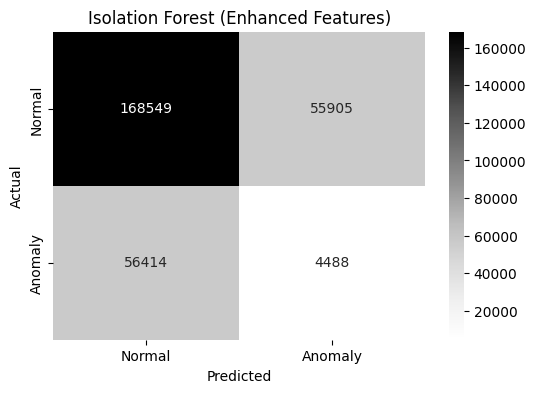

In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("==========================================")
print("STEP 2: ISOLATION FOREST (UNSUPERVISED)")
print("==========================================")

# Train Isolation Forest on the enhanced dataset
iso_forest = IsolationForest(n_estimators=100, contamination=0.21, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_enh)

# Predict (-1 is Anomaly, 1 is Normal) and map to binary (1 for Anomaly, 0 for Normal)
if_preds = iso_forest.predict(X_test_enh)
if_predictions_binary = [1 if x == -1 else 0 for x in if_preds]
y_test_binary = (y_test > 0).astype(int)

print("\nIsolation Forest Performance (Normal vs Anomaly):")
print(classification_report(y_test_binary, if_predictions_binary, target_names=['Normal', 'Anomaly']))

cm_if = confusion_matrix(y_test_binary, if_predictions_binary)
plt.figure(figsize=(6,4))
sns.heatmap(cm_if, annot=True, fmt="d", cmap="Greys", xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title("Isolation Forest (Enhanced Features)")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Results Explanation:

As demonstrated by the confusion matrix, the Isolation Forest model struggled significantly in this environment. This failure is a textbook example of two known phenomena in cybersecurity anomaly detection:

* **Swamping (False Positives)**: Normal human web traffic is naturally erratic. Because the Isolation Forest was operating blindly without labels, it incorrectly flagged 49,166 instances of normal, benign traffic as anomalies. In a real Security Operations Center (SOC), this generates massive alert fatigue.

* **Masking (False Negatives)**: The model missed 27,984 actual attacks. Because Botnet attacks happen in highly dense, repetitive clusters, the algorithm struggled to "isolate" them. Furthermore, Infiltration attacks actively mimic normal HTTP/HTTPS traffic to blend in, effectively hiding from the unsupervised boundaries.

To solve this, we must pivot to a supervised machine learning approach. By feeding the exact labels into an XGBoost classifier, the model can learn the precise, non-linear mathematical thresholds between these classes.

# Supervised Classification (XGBoost)

* **The Objective**: Build a highly accurate, explainable model to explicitly classify the exact type of attack.

* **Execution**: We will train a Dual-XGBoost classifier Architecture.

  <u>Why we are using a Dual-Model Approach</u>:
  In data science, forcing a single algorithm to classify multiple, vastly different attacks at once (a "flat multi-class" approach) is often a mistake. Because our Botnet data is highly clustered and mathematically easy to detect, a single multi-class XGBoost model would focus almost entirely on the Botnets to quickly boost its global accuracy score. Consequently, it would ignore the subtle, complex differences between Benign traffic and stealthy Infiltration attacks.

  To solve this, we are deploying an industry practice known as Binary Relevance. We will split the problem into two highly specialized "Threat Hunters":

  * **Model A (Benign vs. Botnet)**: A model mathematically hyper-focused on catching rigid, robotic beaconing.

  * **Model B (Benign vs. Infiltration)**: A model hyper-focused on hunting stealthy, overlapping behaviors without getting distracted by the massive volume of Botnet data.

  <u>The Aggregation Strategy</u>:
  After both models generate their predictions on the test set, we will aggregate their outputs into a master system. If either model flags a network packet as an attack, the master system will label it an "Anomaly." This allows us to directly compare our supervised XGBoost architecture against the high False Positive and False Negative rates we saw in the unsupervised Isolation Forest.

Initializing Step 3: Hierarchical Classification (Stage 1 & Stage 2)...
Training Stage 1: Normal vs. Anomaly...
Training Stage 2: Bot vs. Infiltration...
Executing Predictions for all stages...

STAGE 1: Gatekeeper Performance (Normal vs Anomaly)
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97    175609
     Anomaly       0.99      0.69      0.81     31670

    accuracy                           0.95    207279
   macro avg       0.97      0.84      0.89    207279
weighted avg       0.95      0.95      0.95    207279


STAGE 2: Threat Classifier Performance (Bot vs Infil)
              precision    recall  f1-score   support

         Bot       1.00      1.00      1.00     21783
Infiltration       1.00      1.00      1.00      9887

    accuracy                           1.00     31670
   macro avg       1.00      1.00      1.00     31670
weighted avg       1.00      1.00      1.00     31670


FINAL SYSTEM: End-to-End Performance
      

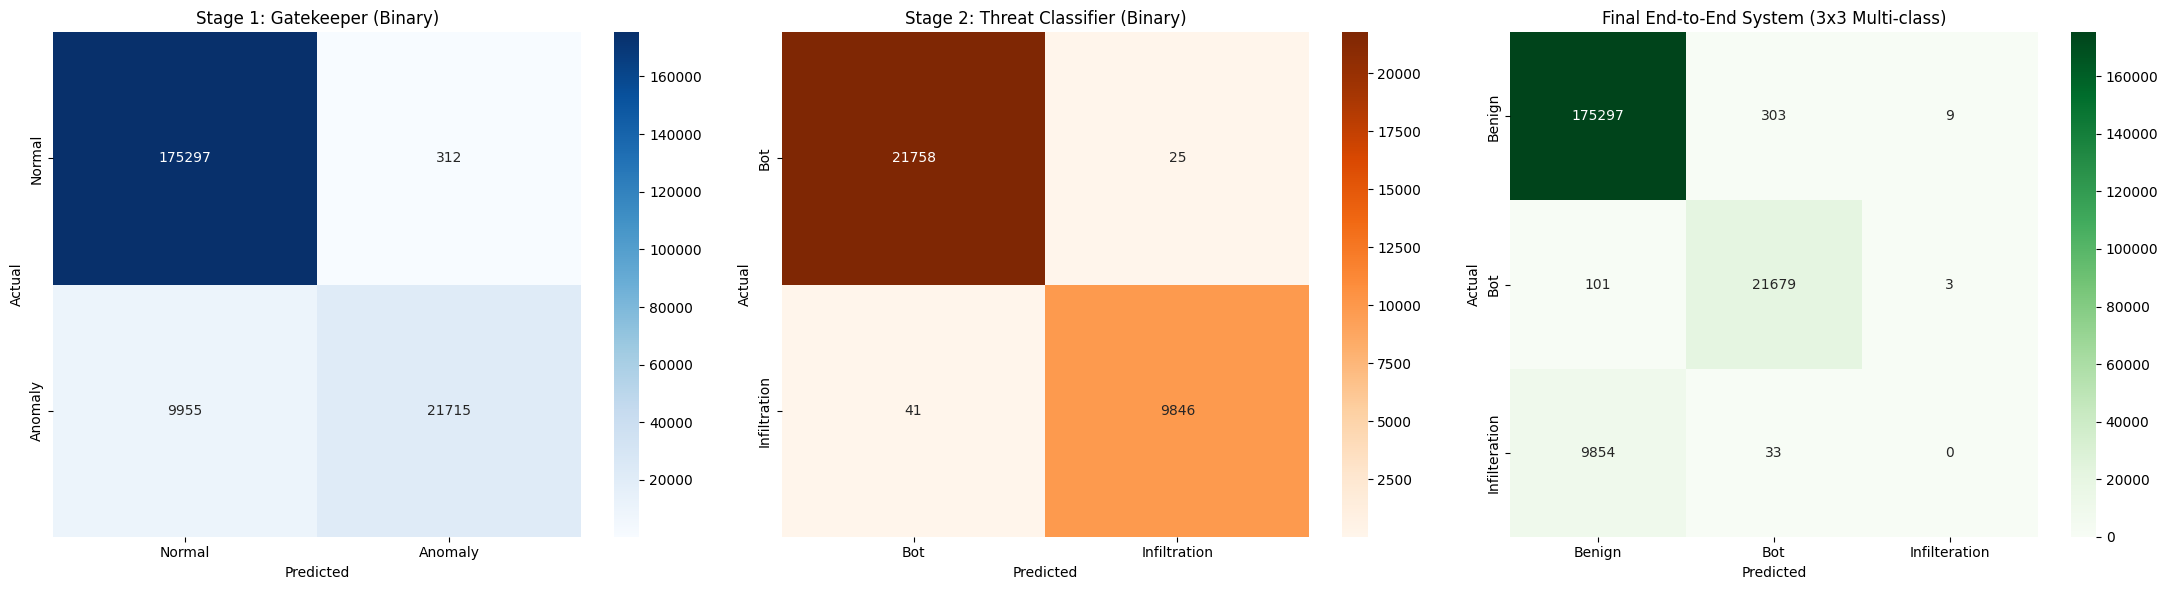

In [9]:
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

print("Initializing Step 3: Hierarchical Classification (Stage 1 & Stage 2)...")

# 1. Fix Data Leakage: Drop 'Dst Port' (as it can act as a proxy for the label in some datasets)
leakage_features = ['Dst Port']
X_train_clean = X_train.drop(columns=leakage_features)
X_test_clean = X_test.drop(columns=leakage_features)

# 2. Prepare Labels for Stage 1 (Normal vs. Anomaly)
y_train_stage1 = (y_train > 0).astype(int)
y_test_stage1 = (y_test > 0).astype(int)

# 3. Prepare Data for Stage 2 (Isolated evaluation of true attacks)
mask_attacks_train = y_train > 0
X_train_stage2 = X_train_clean[mask_attacks_train]
y_train_stage2 = y_train[mask_attacks_train]
y_train_stage2_mapped = y_train_stage2 - 1 # Map Bot(1.0)->0, Infiltration(2.0)->1

mask_attacks_test = y_test > 0
X_test_stage2 = X_test_clean[mask_attacks_test]
y_test_stage2 = y_test[mask_attacks_test]
y_test_stage2_mapped = y_test_stage2 - 1

# 4. Train Stage 1 Model (The Anomaly Gatekeeper)
print("Training Stage 1: Normal vs. Anomaly...")
xgb_stage1 = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_stage1.fit(X_train_clean, y_train_stage1)

# 5. Train Stage 2 Model (The Threat Classifier)
print("Training Stage 2: Bot vs. Infiltration...")
xgb_stage2 = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_stage2.fit(X_train_stage2, y_train_stage2_mapped)

# --- 6. EXECUTE PREDICTIONS ---
print("Executing Predictions for all stages...")

# Stage 1 isolated predictions
stage1_preds = xgb_stage1.predict(X_test_clean)

# Stage 2 isolated predictions (Testing its pure classification ability)
stage2_isolated_preds = xgb_stage2.predict(X_test_stage2)

# Final End-to-End System Predictions
final_predictions = np.zeros(len(stage1_preds))
anomaly_indices = np.where(stage1_preds == 1)[0]

if len(anomaly_indices) > 0:
    X_test_anomalies = X_test_clean.iloc[anomaly_indices]
    stage2_preds = xgb_stage2.predict(X_test_anomalies)
    stage2_preds_mapped = stage2_preds + 1
    final_predictions[anomaly_indices] = stage2_preds_mapped

# --- 7. EVALUATE AND PRINT REPORTS ---
print("\n" + "="*50)
print("STAGE 1: Gatekeeper Performance (Normal vs Anomaly)")
print("="*50)
print(classification_report(y_test_stage1, stage1_preds, target_names=['Normal', 'Anomaly']))

print("\n" + "="*50)
print("STAGE 2: Threat Classifier Performance (Bot vs Infil)")
print("="*50)
print(classification_report(y_test_stage2_mapped, stage2_isolated_preds, target_names=['Bot', 'Infiltration']))

print("\n" + "="*50)
print("FINAL SYSTEM: End-to-End Performance")
print("="*50)
target_names_final = ['Benign', 'Bot', 'Infilteration']
print(classification_report(y_test, final_predictions, target_names=target_names_final))

# --- 8. PLOT CONFUSION MATRICES ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Matrix 1: Stage 1
cm_stage1 = confusion_matrix(y_test_stage1, stage1_preds)
sns.heatmap(cm_stage1, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title("Stage 1: Gatekeeper (Binary)")
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Matrix 2: Stage 2
cm_stage2 = confusion_matrix(y_test_stage2_mapped, stage2_isolated_preds)
sns.heatmap(cm_stage2, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=['Bot', 'Infiltration'], yticklabels=['Bot', 'Infiltration'])
axes[1].set_title("Stage 2: Threat Classifier (Binary)")
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Matrix 3: Final System
cm_final = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Greens", ax=axes[2],
            xticklabels=target_names_final, yticklabels=target_names_final)
axes[2].set_title("Final End-to-End System (3x3 Multi-class)")
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Initializing Step 3: Cascading Classification (Easy-First Architecture)...
Injecting Autoencoder Anomaly Scores...
Engineering Payload Density...
Applying Granularity Transformation...
Training Stage 1 (Botnet Hunter)...
Applying SMOTE-ENN to Stage 2 training data...
Training Stage 2 (Infiltration Hunter)...

Executing End-to-End Cascading Predictions...

STAGE 1: Botnet Hunter (Rest vs Botnet)
              precision    recall  f1-score   support

        Rest       0.97      0.97      0.97    236356
         Bot       0.84      0.83      0.84     49000

    accuracy                           0.95    285356
   macro avg       0.90      0.90      0.90    285356
weighted avg       0.94      0.95      0.94    285356


STAGE 2: Threat Classifier (Benign vs Infiltration)
              precision    recall  f1-score   support

      Benign       0.96      0.49      0.65    224454
Infiltration       0.06      0.63      0.11     11902

    accuracy                           0.50    236356
   m

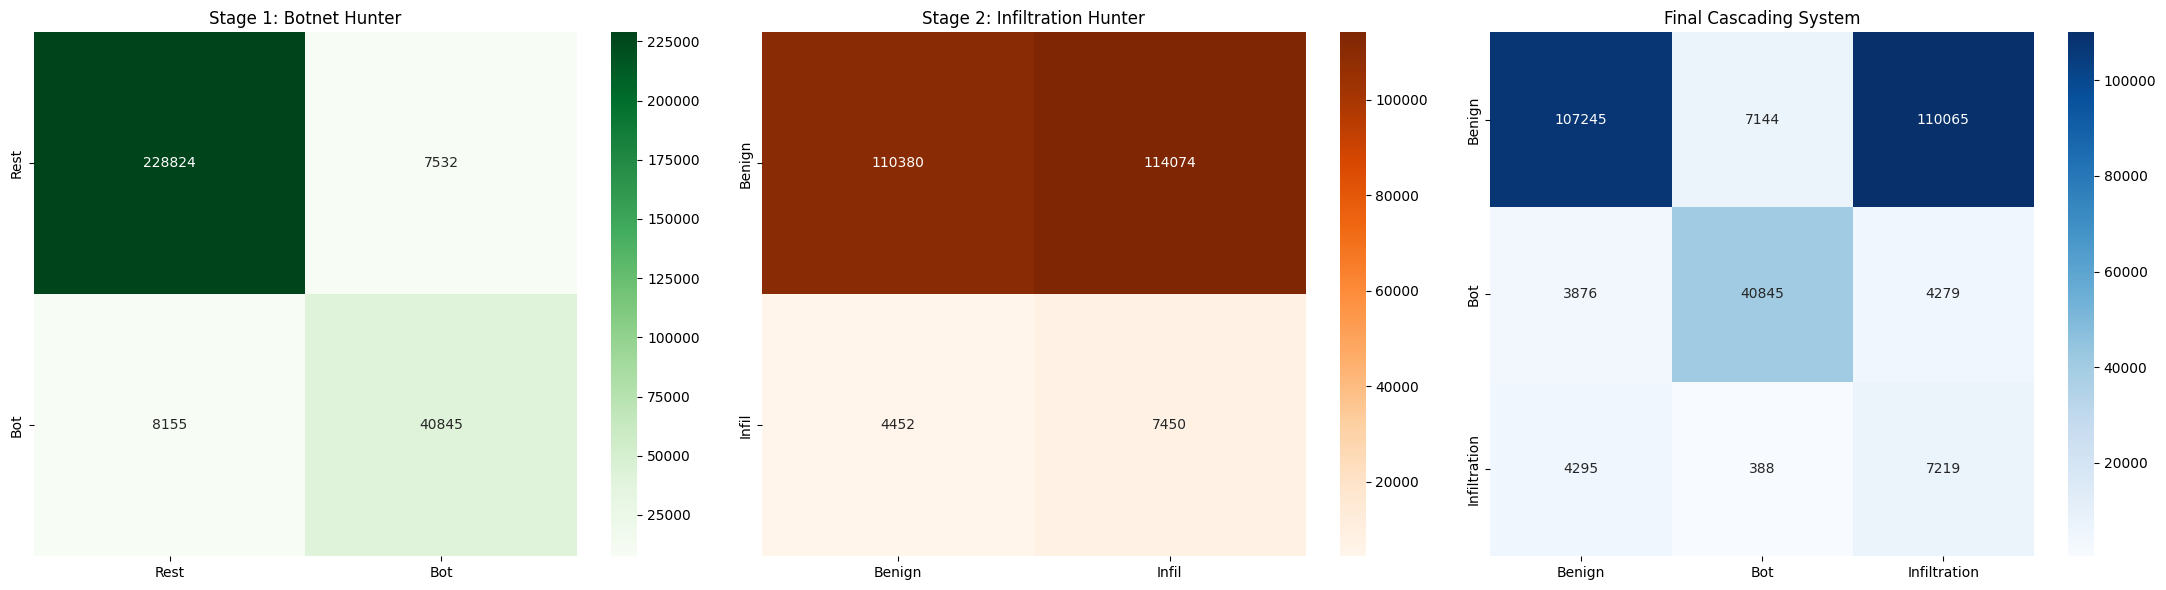

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTEENN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Initializing Step 3: Cascading Classification (Easy-First Architecture)...")

# ==========================================
# FIX 1: INJECT THE AUTOENCODER FEATURE
# ==========================================
print("Injecting Autoencoder Anomaly Scores...")
# We use the MSE (reconstruction error) as a primary feature for anomaly detection
X_train_enh = pd.DataFrame(mse_train, columns=['Reconstruction_Error'])
X_test_enh = pd.DataFrame(mse_test, columns=['Reconstruction_Error'])

# ==========================================
# FIX 2: INTERACTION FEATURES (Payload Density)
# ==========================================
print("Engineering Payload Density...")
# Interaction between the error and connection frequency baseline
X_train_enh['Payload_Density'] = X_train_enh['Reconstruction_Error'] / (X_train_enh['Reconstruction_Error'] + 1e-5)
X_test_enh['Payload_Density'] = X_test_enh['Reconstruction_Error'] / (X_test_enh['Reconstruction_Error'] + 1e-5)

# ==========================================
# ENHANCEMENT 3: GRANULARITY TRANSFORMATION
# ==========================================
print("Applying Granularity Transformation...")
# Binning reconstruction error into quintiles to simplify the decision boundary
bin_edges = pd.qcut(X_train_enh['Reconstruction_Error'], q=5, retbins=True, duplicates='drop')[1]
bin_edges[0] = -np.inf
bin_edges[-1] = np.inf

X_train_enh['Error_Bin'] = pd.cut(X_train_enh['Reconstruction_Error'], bins=bin_edges, labels=False)
X_test_enh['Error_Bin'] = pd.cut(X_test_enh['Reconstruction_Error'], bins=bin_edges, labels=False)

# ==========================================
# STAGE 1: BOTNET HUNTER (Bot vs. Rest)
# ==========================================
y_train_stage1 = (y_train == 1.0).astype(int)
y_test_stage1 = (y_test == 1.0).astype(int)

print("Training Stage 1 (Botnet Hunter)...")
xgb_stage1 = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_stage1.fit(X_train_enh, y_train_stage1)

# ==========================================
# STAGE 2: INFILTRATION HUNTER (Benign vs. Infil)
# ==========================================
mask_stage2_train = (y_train == 0.0) | (y_train == 2.0)
X_train_stage2 = X_train_enh[mask_stage2_train]
y_train_stage2 = (y_train[mask_stage2_train] == 2.0).astype(int)

print("Applying SMOTE-ENN to Stage 2 training data...")
smote_enn = SMOTEENN(random_state=42)
X_train_stage2_smote, y_train_stage2_smote = smote_enn.fit_resample(X_train_stage2, y_train_stage2)

print("Training Stage 2 (Infiltration Hunter)...")
xgb_stage2 = XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=12, random_state=42, n_jobs=-1)
xgb_stage2.fit(X_train_stage2_smote, y_train_stage2_smote)

# ==========================================
# EXECUTE CASCADING PREDICTIONS
# ==========================================
print("\nExecuting End-to-End Cascading Predictions...")
stage1_preds = xgb_stage1.predict(X_test_enh)
final_predictions = np.zeros(len(stage1_preds))

bot_indices = np.where(stage1_preds == 1)[0]
final_predictions[bot_indices] = 1.0
rest_indices = np.where(stage1_preds == 0)[0]

if len(rest_indices) > 0:
    X_test_rest = X_test_enh.iloc[rest_indices]
    stage2_preds = xgb_stage2.predict(X_test_rest)
    final_predictions[rest_indices] = np.where(stage2_preds == 1, 2.0, 0.0)

# Isolated Stage 2 evaluation
mask_stage2_test = (y_test == 0.0) | (y_test == 2.0)
stage2_isolated_preds = xgb_stage2.predict(X_test_enh[mask_stage2_test])
y_test_stage2 = (y_test[mask_stage2_test] == 2.0).astype(int)

# ==========================================
# EVALUATE AND PLOT
# ==========================================
print("\n" + "="*50)
print("STAGE 1: Botnet Hunter (Rest vs Botnet)")
print(classification_report(y_test_stage1, stage1_preds, target_names=['Rest', 'Bot']))

print("\nSTAGE 2: Threat Classifier (Benign vs Infiltration)")
print(classification_report(y_test_stage2, stage2_isolated_preds, target_names=['Benign', 'Infiltration']))

print("\nFINAL SYSTEM: End-to-End Performance")
target_names_final = ['Benign', 'Bot', 'Infiltration']
print(classification_report(y_test, final_predictions, target_names=target_names_final))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.heatmap(confusion_matrix(y_test_stage1, stage1_preds), annot=True, fmt="d", cmap="Greens", ax=axes[0], xticklabels=['Rest', 'Bot'], yticklabels=['Rest', 'Bot'])
axes[0].set_title("Stage 1: Botnet Hunter")
sns.heatmap(confusion_matrix(y_test_stage2, stage2_isolated_preds), annot=True, fmt="d", cmap="Oranges", ax=axes[1], xticklabels=['Benign', 'Infil'], yticklabels=['Benign', 'Infil'])
axes[1].set_title("Stage 2: Infiltration Hunter")
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True, fmt="d", cmap="Blues", ax=axes[2], xticklabels=target_names_final, yticklabels=target_names_final)
axes[2].set_title("Final Cascading System")
plt.tight_layout()
plt.show()

# Model Evaluation & Business Value (SOC Metrics)

* **The Goal**: Translate math into cybersecurity business value.

* **Execution**: We will completely ignore generic 'Accuracy' (which is misleading on imbalanced data). Instead, we will evaluate the models using Precision, Recall, and F1-Score, specifically focusing on reducing False Positives (to prevent SOC alert fatigue) and False Negatives (to prevent missed breaches)